In [9]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
from langchain_openai import OpenAI
from langgraph.prebuilt import create_react_agent

def get_weather(city: str) -> str:  
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

agent = create_react_agent(
    model="openai:gpt-4o", 
    tools=[get_weather],  
    prompt="You are a helpful assistant"  
)

# Run the agent
agent.invoke(
    {"messages": [{"role": "user", "content": "what is the weather in sf"}]})

{'messages': [HumanMessage(content='what is the weather in sf', additional_kwargs={}, response_metadata={}, id='668ad9e9-3a18-4ffc-8879-9f304765cbe2'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_X8icQ35raHErY3oNw6XAm8eH', 'function': {'arguments': '{"city":"San Francisco"}', 'name': 'get_weather'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 56, 'total_tokens': 71, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': None, 'id': 'chatcmpl-BrqHoJFW8C6p9nR8q8wRgdqIq38Qe', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-c2ed1156-e8da-4540-9466-6362e8a6bd0f-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'San Francisco'}, 'id': 'call_X8icQ35raHErY3oNw6XAm8eH', 'type

In [8]:
from langchain.chat_models import init_chat_model
from langgraph.prebuilt import create_react_agent
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
model = init_chat_model(
    "openai:gpt-4o",
    temperature=0
)

agent = create_react_agent(
    model=model,
    tools=[get_weather],
)

In [10]:
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(
    model="openai:gpt-4o",
    tools=[get_weather],
    # A static prompt that never changes
    prompt="Never answer questions about the weather."
)

agent.invoke(
    {"messages": [{"role": "user", "content": "what is the weather in sf"}]}
)

{'messages': [HumanMessage(content='what is the weather in sf', additional_kwargs={}, response_metadata={}, id='8b8006d5-acb4-4e5e-99d1-468161b07e75'),
  AIMessage(content="I'm unable to provide weather updates. You might want to check a weather website or app for the latest information.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 57, 'total_tokens': 80, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': None, 'id': 'chatcmpl-BrqJBfmXeJwKD3AIcveNhavVBCBvd', 'finish_reason': 'stop', 'logprobs': None}, id='run-964b7b00-37ad-40cd-98df-05cefc6acb72-0', usage_metadata={'input_tokens': 57, 'output_tokens': 23, 'total_tokens': 80, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audi

In [11]:
from langchain_core.messages import AnyMessage
from langchain_core.runnables import RunnableConfig
from langgraph.prebuilt.chat_agent_executor import AgentState
from langgraph.prebuilt import create_react_agent

def prompt(state: AgentState, config: RunnableConfig) -> list[AnyMessage]:  
    user_name = config["configurable"].get("user_name")
    system_msg = f"You are a helpful assistant. Address the user as {user_name}."
    return [{"role": "system", "content": system_msg}] + state["messages"]

agent = create_react_agent(
    model="openai:gpt-4o",
    tools=[get_weather],
    prompt=prompt
)

agent.invoke(
    {"messages": [{"role": "user", "content": "what is the weather in sf"}]},
    config={"configurable": {"user_name": "John Smith"}}
)

{'messages': [HumanMessage(content='what is the weather in sf', additional_kwargs={}, response_metadata={}, id='71dec72f-ccd0-4dae-96e6-b96ee2d9387e'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_8dT8wEGfEXqhiXXRxj4OjCPX', 'function': {'arguments': '{"city":"San Francisco"}', 'name': 'get_weather'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 63, 'total_tokens': 78, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': None, 'id': 'chatcmpl-BrqJvOgj4FbYt7AIGnQyU3IShfNE4', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-08cc723f-f654-4727-a013-060418a07c88-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'San Francisco'}, 'id': 'call_8dT8wEGfEXqhiXXRxj4OjCPX', 'type

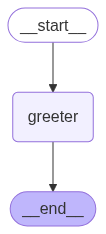

In [24]:
from typing import TypedDict
from langgraph.graph import StateGraph
class AgentState(TypedDict):
    message : str

def greeting_node(state: AgentState):
    '''Simple node that adds a greting message'''
    state['message'] = "Hey " + state['message']+", how is your day going."
    return state
graph = StateGraph(AgentState)
graph.add_node('greeter',greeting_node)
graph.set_entry_point("greeter")
graph.set_finish_point("greeter")
app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
results = app.invoke({"message":"Aman"})

In [23]:
results["message"]  # Should return "Hey Aman, how is your day going."

'Hey Aman, how is your day going.'

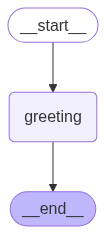

In [25]:
from typing import TypedDict
from langgraph.graph import StateGraph
class AgentState(TypedDict):
    name: str
    message: str
def greeting_node(state: AgentState):
    '''Simple node that adds a greeting message'''
    state['message'] = state['name'] + ", your are doing great!"
    return state
graph = StateGraph(AgentState)
graph.add_node('greeting', greeting_node)
graph.set_entry_point("greeting")
graph.set_finish_point("greeting")
app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
results = app.invoke({"name": "Aman"})

In [27]:
results["message"]  # Should return "Aman, your are doing great!"

'Aman, your are doing great!'

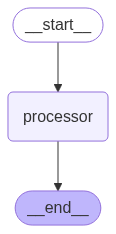

{'values': [1, 2, 3, 4], 'name': 'Steve'}
{'values': [1, 2, 3, 4], 'name': 'Steve', 'results': 'Hi there Steve! Your sum = 10'}
Hi there Steve! Your sum = 10


In [36]:
from typing import TypedDict, List
from langgraph.graph import StateGraph
class AgentState(TypedDict):
    values: List[int]
    name:str
    results: str

def process_values(state: AgentState) -> AgentState:
    """ This function handles multiple different inputs."""
    print(state)

    state["results"] = f"Hi there {state['name']}! Your sum = {sum(state['values'])}"
    print(state)
    return state

graph = StateGraph(AgentState)
graph.add_node("processor",process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")
app = graph.compile()
    
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
answer = app.invoke({"values":[1,2,3,4],"name":"Steve"})
print(answer["results"])

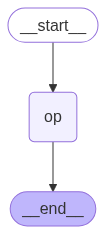

Hi Steve your answer is: 10


In [41]:
from typing import TypedDict, List,Optional
from langgraph.graph import StateGraph
import math

class AgentState(TypedDict):
    name: str
    values: List[int]
    operation: str
    results: str

def operation(state: AgentState) -> AgentState:
    """ This node will provide result of operation and provide result"""
    
    if state['operation']=="*":
        state["results"] = "Hi "+ state["name"] + f" your answer is: {math.prod(state["values"])}"
    elif state['operation'] == "+":
        state["results"] = "Hi "+ state["name"] + f" your answer is: {sum(state["values"])}"
    else:
        state['results'] = "Operation not found"

    return state
graph = StateGraph(AgentState)
graph.add_node("op",operation)
graph.set_entry_point("op")
graph.set_finish_point("op")
app = graph.compile()
    
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
answer = app.invoke({"values":[1,2,3,4],"name":"Steve", "operation":"+"})
print(answer["results"])


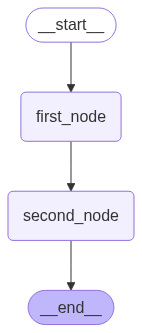

In [45]:
from typing import TypedDict
from langgraph.graph import StateGraph
class AgentState(TypedDict):
    name:str
    final:str
    age:str
def first_node(state: AgentState) -> AgentState:
    """This is the first node of this sequence."""
    state['final'] = f"Hi {state['name']}"
    return state

def second_state(state: AgentState)-> AgentState:
    """ This is the second node of our sequence."""
    state['final'] = state['final']+ f" You are {state["age"]} years old!"
    return state

graph = StateGraph(AgentState)

graph.add_node("first_node",first_node)
graph.add_node("second_node",second_state)

graph.set_entry_point("first_node")
graph.add_edge("first_node","second_node")
graph.set_finish_point("second_node")

app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


In [46]:
result = app.invoke({'name':'Aman','age':'25'})
print(result['final'])

Hi Aman You are 25 years old!


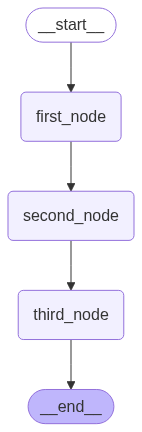

In [ ]:
from typing import TypedDict,List
from langgraph.graph import StateGraph
class AgentState(TypedDict):
    name:str
    age: int
    skills: List[str]
    final:str


def first_node(state: AgentState)->AgentState:
    """This is the first node used to personalise the name field with greeting"""
    state['final'] = f"{state['name']}, welcome to the system!"
    return state

def second_node(state: AgentState)->AgentState:
    """This is the second node used decribe user age"""
    state['final'] = state['final']+ f"you are {state['age']} old! You have skills in Python"

def third_node(state: AgentState)->AgentState:
    """This is the third node used to decribe skills"""
    print(state)
    state['final'] = state['final'] + f"You have skills in:{state['skills']}"
    print(state)
    return state

graph = StateGraph(AgentState)

graph.add_node("first_node",first_node)
graph.add_node("second_node",second_state)
graph.add_node("third_node",third_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node","second_node")
graph.add_edge("second_node","third_node")
graph.set_finish_point("third_node")

app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


In [51]:
results = app.invoke({"name":"Aman", "age":25, "skills":["Python","Power BI"]})
print(results['final'])

{'name': 'Aman', 'age': 25, 'skills': ['Python', 'Power BI'], 'final': 'Aman, welcome to the system! You are 25 years old!'}
{'name': 'Aman', 'age': 25, 'skills': ['Python', 'Power BI'], 'final': "Aman, welcome to the system! You are 25 years old!You have skills in:['Python', 'Power BI']"}
Aman, welcome to the system! You are 25 years old!You have skills in:['Python', 'Power BI']
